In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

In [ ]:
# Generate dummy dataset
data = np.random.rand(10000, 20)

In [ ]:
input_dim = 20
latent_dim = 2

# Encoder
inputs = Input(shape=(input_dim,))
h = Dense(10, activation='relu')(inputs)

z_mean = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)

# Sampling function
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling)([z_mean, z_log_var])

In [ ]:
decoder_h = Dense(10, activation='relu')
decoder_output = Dense(input_dim, activation='sigmoid')

h_decoded = decoder_h(z)
outputs = decoder_output(h_decoded)

In [ ]:
vae = Model(inputs, outputs)

In [ ]:
class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        original_inputs, reconstructions, z_mean, z_log_var = inputs

        # Reconstruction loss (mean squared error)
        reconstruction_loss = tf.reduce_mean(
            tf.square(original_inputs - reconstructions)
        )

        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        total_vae_loss = reconstruction_loss + kl_loss
        self.add_loss(total_vae_loss)

        return reconstructions # This layer should output the reconstructions

# Integrate the custom loss layer into the model
outputs_with_loss = VAELossLayer()([inputs, outputs, z_mean, z_log_var])

vae = Model(inputs, outputs_with_loss)
vae.compile(optimizer='adam') # No loss needed here, it's added internally by the layer

vae.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │        210 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │         22 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2)         │         22 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2)         │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │         30 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 20)        │        220 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss_layer      │ (None, 20)        │          0 │ input_layer[0][0… │
│ (VAELossLayer)      │                   │            │ dense_4[0][0],    │
│                     │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 504 (1.97 KB)

 Trainable params: 504 (1.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = vae.fit(
    data,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0971 - val_loss: 0.0853
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0846 - val_loss: 0.0844
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0839 - val_loss: 0.0841
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0837 - val_loss: 0.0840
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0836 - val_loss: 0.0839
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0836 - val_loss: 0.0839
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0836 - val_loss: 0.0839
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0835 - val_loss: 0.0839
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0835 - val_loss: 0.0839
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0835 - val_loss: 0.0839
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0835 - val_loss: 0.0839
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

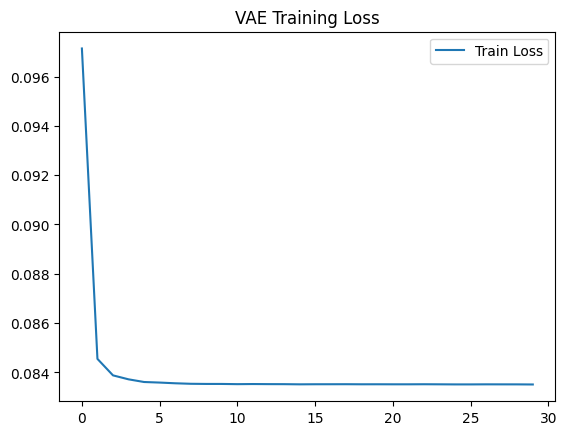

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.title("VAE Training Loss")
plt.legend()
plt.show()

In [ ]:
# Create decoder model separately
decoder_input = Input(shape=(latent_dim,))
_decoded_h = decoder_h(decoder_input)
_decoded_output = decoder_output(_decoded_h)

decoder = Model(decoder_input, _decoded_output)

# Generate new samples
z_sample = np.random.normal(size=(5, latent_dim))
generated_data = decoder.predict(z_sample)

print("Generated Data:\n", generated_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Generated Data:
 [[0.49436653 0.49743754 0.49792004 0.50086725 0.49916196 0.5019635
  0.50237167 0.498804   0.5008462  0.50313926 0.49546295 0.4953701
  0.5031686  0.49912608 0.5068555  0.49856108 0.49927986 0.50116885
  0.5057898  0.49434966]
 [0.4937733  0.49512523 0.49489963 0.5009073  0.5029195  0.50287724
  0.49676013 0.498102   0.49948984 0.503741   0.49760982 0.49784482
  0.5003023  0.5012368  0.5005565  0.4973698  0.49998796 0.49775776
  0.50673974 0.49409306]
 [0.49259177 0.49613792 0.4971097  0.50034964 0.49767223 0.50105405
  0.5023538  0.49848366 0.4999354  0.50325465 0.49558145 0.4955423
  0.50180584 0.49980843 0.5058522  0.49871913 0.49944264 0.50117177
  0.5045981  0.4950087 ]
 [0.49436653 0.49743754 0.49792004 0.50086725 0.49916196 0.5019635
  0.50237167 0.498804   0.5008462  0.50313926 0.49546295 0.4953701
  0.5031686  0.49912608 0.5068555  0.49856108 0.49927986 0.50116885
  0.5057898  0.49434966]
 [0.4880967  0.49111527 0.49706742

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [ ]:
# Real data (Gaussian distribution)
def get_real_data(n=1000):
    return np.random.normal(loc=0, scale=1, size=(n, 1))

In [ ]:
def build_generator():
    model = Sequential([
        Dense(16, activation='relu', input_dim=10),
        Dense(8, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model

In [ ]:
def build_discriminator():
    model = Sequential([
        Dense(16, activation='relu', input_dim=1),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def build_gan(generator, discriminator):
    discriminator.trainable = False

    model = Sequential([generator, discriminator])
    model.compile(optimizer='adam', loss='binary_crossentropy')

    return model

In [ ]:
generator = build_generator()
discriminator = build_discriminator()
gan = build_gan(generator, discriminator)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
epochs = 1000
batch_size = 32

d_losses = []
g_losses = []

for epoch in range(epochs):

    # ---------------------
    # Train Discriminator
    # ---------------------

    real_data = get_real_data(batch_size)
    real_labels = np.ones((batch_size, 1))

    noise = np.random.normal(0, 1, (batch_size, 10))
    fake_data = generator.predict(noise, verbose=0)
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_data, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ---------------------
    # Train Generator
    # ---------------------

    noise = np.random.normal(0, 1, (batch_size, 10))
    misleading_labels = np.ones((batch_size, 1))

    g_loss = gan.train_on_batch(noise, misleading_labels)

    d_losses.append(d_loss[0])
    g_losses.append(g_loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.6681 | G Loss: 0.6852
Epoch 100 | D Loss: 0.6867 | G Loss: 0.6718
Epoch 200 | D Loss: 0.7362 | G Loss: 0.5989
Epoch 300 | D Loss: 0.8691 | G Loss: 0.4830
Epoch 400 | D Loss: 1.0741 | G Loss: 0.3835
Epoch 500 | D Loss: 1.2956 | G Loss: 0.3135
Epoch 600 | D Loss: 1.5048 | G Loss: 0.2641
Epoch 700 | D Loss: 1.6947 | G Loss: 0.2279
Epoch 800 | D Loss: 1.8655 | G Loss: 0.2003
Epoch 900 | D Loss: 2.0188 | G Loss: 0.1786


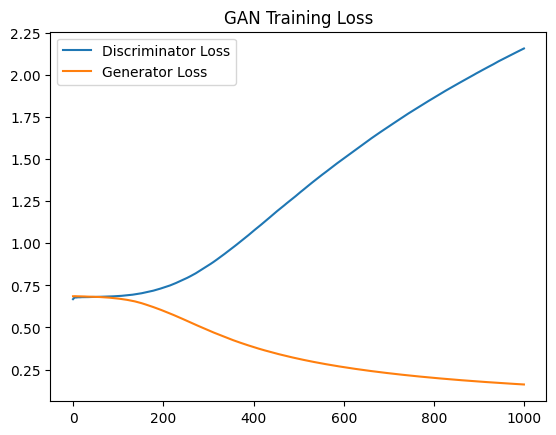

In [ ]:
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.legend()
plt.title("GAN Training Loss")
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


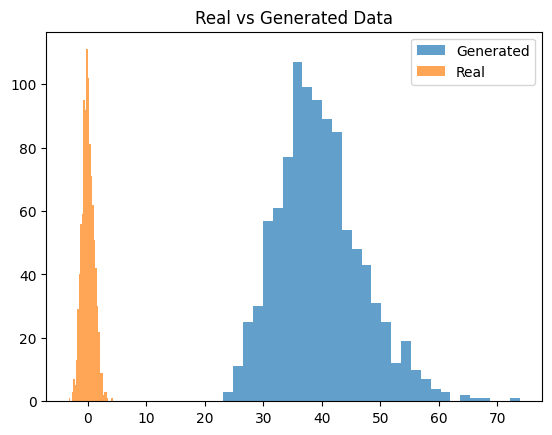

In [ ]:
noise = np.random.normal(0, 1, (1000, 10))
generated_data = generator.predict(noise)

plt.hist(generated_data, bins=30, alpha=0.7, label='Generated')
plt.hist(get_real_data(1000), bins=30, alpha=0.7, label='Real')
plt.legend()
plt.title("Real vs Generated Data")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

In [ ]:
# Adjacency matrix (graph structure)
adj = torch.tensor([
    [1,1,0,0],
    [1,1,1,0],
    [0,1,1,1],
    [0,0,1,1]
], dtype=torch.float32)

# Node features (each node has 10 features)
features = torch.rand((4,10))

# Labels for nodes (classification)
labels = torch.tensor([0, 1, 0, 1])

In [ ]:
def normalize_adj(adj):
    D = torch.diag(torch.sum(adj, dim=1))
    D_inv = torch.inverse(D)
    return torch.matmul(D_inv, adj)

adj_norm = normalize_adj(adj)

In [ ]:
class SimpleGCN(nn.Module):
    def __init__(self):
        super(SimpleGCN, self).__init__()
        self.fc1 = nn.Linear(10, 8)
        self.fc2 = nn.Linear(8, 2)

    def forward(self, x, adj):
        x = torch.matmul(adj, x)   # Graph convolution
        x = self.fc1(x)
        x = F.relu(x)

        x = torch.matmul(adj, x)
        x = self.fc2(x)

        return x

In [ ]:
model = SimpleGCN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
epochs = 100

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    output = model(features, adj_norm)

    loss = loss_fn(output, labels)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6945
Epoch 10, Loss: 0.6788
Epoch 20, Loss: 0.6636
Epoch 30, Loss: 0.6447
Epoch 40, Loss: 0.6263
Epoch 50, Loss: 0.6146
Epoch 60, Loss: 0.6086
Epoch 70, Loss: 0.6031
Epoch 80, Loss: 0.5946
Epoch 90, Loss: 0.5820


In [ ]:
model.eval()

with torch.no_grad():
    output = model(features, adj_norm)
    predictions = torch.argmax(output, dim=1)

print("Predictions:", predictions)
print("Actual Labels:", labels)

Predictions: tensor([0, 0, 1, 1])
Actual Labels: tensor([0, 1, 0, 1])


In [ ]:
accuracy = (predictions == labels).sum().item() / len(labels)
print("Accuracy:", accuracy)

Accuracy: 0.5
